
Retrieval-Augmented Generation pipeline:

| Stage | Process |
|---|---|
| 1. Preprocessing  | Upload ; Parse ; Chunk ; Embed ; Store |
| 2. Inner Process | Query ; Dense retrieval ; BM25 ; RRF Fusion ; Reranking |
| 3. Evaluation | Auto-generate QA pairs ; Run RAG ; Score with Faithfulness, Relevancy, Context Precision/Recall, BLEU/ROUGE |


Models used
Embedder: BAAI/bge-base-en-v1.5 

Reranker: cross-encoder/ms-marco-MiniLM-L-6-v2
 
LLM: llama-3.3-70b-versatile

0. Install & Import Dependencies

In [41]:
# Install all required packages (run once)
!pip install sentence-transformers chromadb rank-bm25 PyMuPDF python-pptx python-docx \
             groq rouge-score nltk numpy pandas matplotlib seaborn ipywidgets --quiet

In [42]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [43]:
import os, re, json, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML, Markdown
import ipywidgets as widgets

warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('Imports done')

Imports done


In [44]:
from dotenv import load_dotenv
import os

load_dotenv()

GROQ_API_KEY = os.getenv('GROQ_API_KEY')

if not GROQ_API_KEY:
    GROQ_API_KEY = input(' Enter your Groq API key: ').strip()

print('API key set')

API key set


STAGE 1: Preprocessing
Upload; Parse; Chunk; Embed; Store in ChromaDB

1.1 Upload Your Document

In [45]:
upload_widget = widgets.FileUpload(
    accept='.pdf,.pptx,.docx,.txt',
    multiple=False,
    description='Upload Document'
)
display(upload_widget)
print('Select your knowledge document above (PDF / PPTX / DOCX / TXT)')

FileUpload(value=(), accept='.pdf,.pptx,.docx,.txt', description='Upload Document')

Select your knowledge document above (PDF / PPTX / DOCX / TXT)


In [47]:
import io

if not upload_widget.value:
    raise ValueError('  No file uploaded. Run the cell above and upload a file first.')

uploaded_item = upload_widget.value[0]  

file_name  = uploaded_item['name']
file_bytes = uploaded_item['content']
file_path  = file_path = file_name

with open(file_path, 'wb') as f:
    f.write(file_bytes)

print(f'Saved: {file_name}  ({len(file_bytes)/1024:.1f} KB)')

Saved: Module 5.pptx  (4880.1 KB)


 1.2 Parse: Extract raw text from the document

In [48]:
import fitz          
import docx as _docx
from pptx import Presentation

def parse_pdf(path, name):
    doc   = fitz.open(path)
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text('text').strip()
        if text:
            pages.append({'text': text, 'page': i+1, 'source': name})
    doc.close()
    return pages

def parse_pptx(path, name):
    prs   = Presentation(path)
    pages = []
    for i, slide in enumerate(prs.slides):
        texts = [s.text.strip() for s in slide.shapes
                 if hasattr(s, 'text') and s.text.strip()]
        if texts:
            pages.append({'text': ' '.join(texts), 'page': i+1, 'source': name})
    return pages

def parse_docx(path, name):
    doc   = _docx.Document(path)
    paras = [p.text.strip() for p in doc.paragraphs if p.text.strip()]
    pages = []
    for i in range(0, len(paras), 20):
        pages.append({'text': ' '.join(paras[i:i+20]),
                      'page': i//20+1, 'source': name})
    return pages

def parse_txt(path, name):
    with open(path, encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    pages = []
    for i in range(0, len(lines), 50):
        text = ''.join(lines[i:i+50]).strip()
        if text:
            pages.append({'text': text, 'page': i//50+1, 'source': name})
    return pages

PARSERS = {'.pdf': parse_pdf, '.pptx': parse_pptx,
           '.docx': parse_docx, '.txt': parse_txt}

def parse_file(path, name=None):
    ext    = Path(path).suffix.lower()
    dname  = name or Path(path).name
    parser = PARSERS.get(ext)
    if not parser:
        raise ValueError(f'Unsupported type: {ext}')
    return parser(path, dname)

pages = parse_file(file_path, file_name)

print(f' Parsed {len(pages)} page-level blocks from "{file_name}"')
print(f'\nPreview: Page')
print(textwrap.fill(pages[0]['text'][:500], 90))
print('...')

 Parsed 45 page-level blocks from "Module 5.pptx"

Preview: Page
Module 5 XAI Methods XAI Techniques - Local Interpretable Model-Agnostic Explanations
(LIME) - Understanding  Mathematical  representation  of  LIME  -  Shapley  Additive
exPlanations (SHAP) - Diverse Counterfactual Explanations (DiCE) - Layer wise Relevance
Propagation (LRP).
...


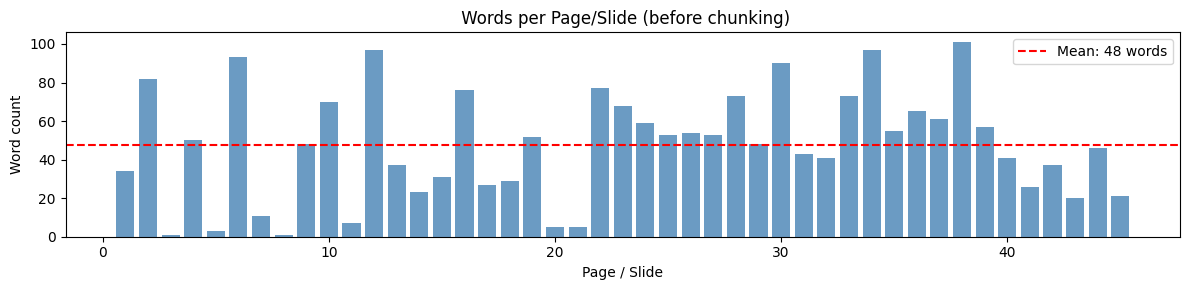

Total words across document: 2,141


In [49]:

lengths = [len(p['text'].split()) for p in pages]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(1, len(lengths)+1), lengths, color='steelblue', alpha=0.8)
ax.axhline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f} words')
ax.set_xlabel('Page / Slide')
ax.set_ylabel('Word count')
ax.set_title(' Words per Page/Slide (before chunking)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total words across document: {sum(lengths):,}')

 1.3 Chunk: Split into overlapping windows

In [50]:
CHUNK_SIZE    = 400
CHUNK_OVERLAP = 80

def split_sentences(text):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

def semantic_chunk(pages):
    chunks = []
    for page in pages:
        sentences = split_sentences(page['text'])
        word_buf, chunk_idx = [], 0
        for sent in sentences:
            sw = sent.split()
            if len(word_buf) + len(sw) > CHUNK_SIZE and word_buf:
                chunks.append({
                    'text':        ' '.join(word_buf),
                    'page':        page['page'],
                    'source':      page['source'],
                    'chunk_index': chunk_idx,
                })
                chunk_idx += 1
                word_buf   = word_buf[-CHUNK_OVERLAP:] + sw
            else:
                word_buf.extend(sw)
        if word_buf:
            chunks.append({'text':' '.join(word_buf),
                           'page':page['page'], 'source':page['source'],
                           'chunk_index':chunk_idx})
    return chunks

chunks = semantic_chunk(pages)
chunk_lens = [len(c['text'].split()) for c in chunks]

print(f' {len(pages)} pages  tp  {len(chunks)} chunks')
print(f'   Avg chunk size : {np.mean(chunk_lens):.0f} words')
print(f'   Min / Max      : {min(chunk_lens)} / {max(chunk_lens)} words')

# Show first 3 chunks as cards
for i, c in enumerate(chunks[:3]):
    display(HTML(f"""
    <div style='border:1px solid #ccc;border-radius:6px;padding:10px;margin:6px 0;
                font-family:monospace;font-size:12px;background:#f9f9f9'>
      <b>Chunk {i} — Page {c['page']} — {len(c['text'].split())} words</b><br/>
      {c['text'][:300]}…
    </div>
    """))

 45 pages  tp  45 chunks
   Avg chunk size : 48 words
   Min / Max      : 1 / 101 words


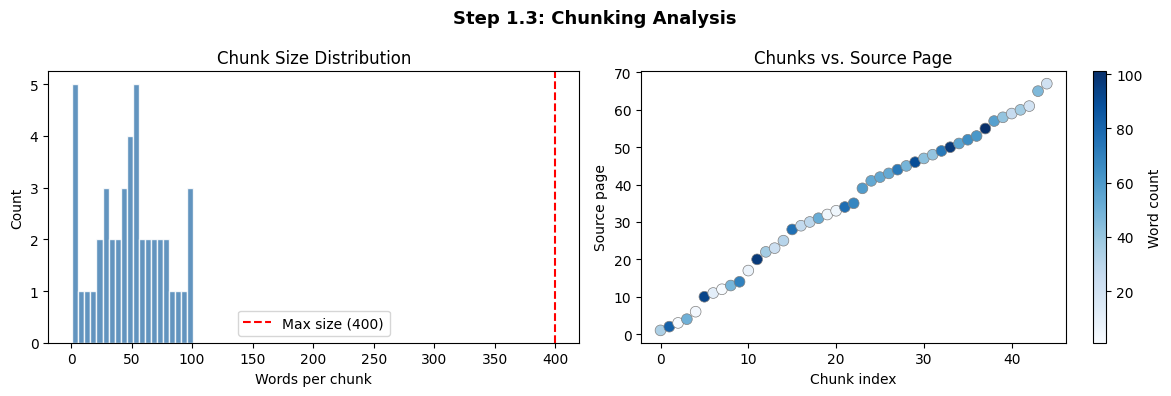

In [51]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chunk_lens, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'Max size ({CHUNK_SIZE})')
axes[0].set_title('Chunk Size Distribution')
axes[0].set_xlabel('Words per chunk')
axes[0].set_ylabel('Count')
axes[0].legend()


n_show = min(len(chunks), 60)
page_nums = [c['page'] for c in chunks[:n_show]]
word_nums = [len(c['text'].split()) for c in chunks[:n_show]]
axes[1].scatter(range(n_show), page_nums, c=word_nums, cmap='Blues', s=60, edgecolors='gray', lw=0.5)
axes[1].set_title('Chunks vs. Source Page')
axes[1].set_xlabel('Chunk index')
axes[1].set_ylabel('Source page')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Word count')

plt.suptitle('Step 1.3: Chunking Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

1.4 Embed: Convert chunks to dense vectors

Model: BAAI/bge-base-en-v1.5 (768-dim)

In [52]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL = 'BAAI/bge-base-en-v1.5'
print(f'Loading embedder: {EMBED_MODEL} ...')
embedder = SentenceTransformer(EMBED_MODEL)

texts      = [c['text'] for c in chunks]
embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=32)

print(f'\n Embedded {len(embeddings)} chunks')
print(f'   Embedding shape: {embeddings.shape}  (chunks × dims)')

Loading embedder: BAAI/bge-base-en-v1.5 ...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


 Embedded 45 chunks
   Embedding shape: (45, 768)  (chunks × dims)


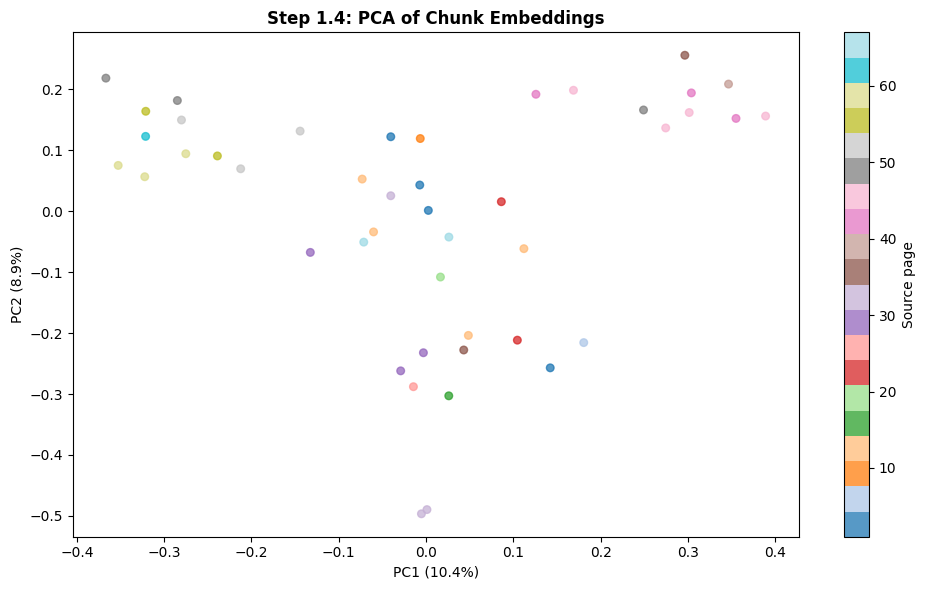

In [53]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
pages_arr = np.array([c['page'] for c in chunks])

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=pages_arr, cmap='tab20', alpha=0.75, s=30)
plt.colorbar(sc, ax=ax, label='Source page')
ax.set_title('Step 1.4: PCA of Chunk Embeddings',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()


1.5 Store: Upsert into ChromaDB

In [54]:
import chromadb

DB_PATH = './chroma_db_demo'
_client = chromadb.PersistentClient(path=DB_PATH)

try:
    _client.delete_collection('rag_demo')
except:
    pass

collection = _client.get_or_create_collection(
    name='rag_demo',
    metadata={'hnsw:space': 'cosine'}
)

ids       = [f'{file_name}__chunk_{i}' for i in range(len(chunks))]
metadatas = [{'source': c['source'], 'page': c['page']} for c in chunks]

collection.upsert(
    ids=ids,
    documents=texts,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)

print(f' Stored {collection.count()} chunks in ChromaDB')
print(f'   Path: {DB_PATH}')
print(f'   Collection: rag_demo')
print(f'   Similarity metric: cosine')

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


 Stored 45 chunks in ChromaDB
   Path: ./chroma_db_demo
   Collection: rag_demo
   Similarity metric: cosine


STAGE 2: Retrieval
Query; Dense; BM25; RRF Fusion; CrossEncoder Reranking

2.1 Enter a Test Query

In [55]:

TEST_QUERY = 'How does LIME explain a black-box model prediction?'

print(f'Query: "{TEST_QUERY}"')

Query: "How does LIME explain a black-box model prediction?"


2.2 Step 1: Dense Retrieval

Dense retrieval → top 20 candidates

Top-5 Dense Results:


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>rank</th>\n      <th>chunk_id</th>\n      <th>similarity</th>\n      <th>preview</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>1</td>\n      <td>5</td>\n      <td>0.8679</td>\n      <td>The explanation produced by LIME is obtained by the following: f → Black-box mod…</td>\n    </tr>\n    <tr>\n      <td>2</td>\n      <td>1</td>\n      <td>0.8526</td>\n      <td>Local Interpretable Model-Agnostic Explanations (LIME) Local Interpretable Model…</td>\n    </tr>\n    <tr>\n      <td>3</td>\n      <td>9</td>\n      <td>0.8509</td>\n      <td>The black-box model’s complex decision function f (unknown to LIME) is represent…</td>\n    </tr>\n    <tr>\n      <td>4</td>\n      <td>0</td>\n      <td>0.7462</td>\n      <td>Module 5 XAI Methods XAI Techniques - Local Interpretable Model-Agnostic Explana…</td>\n    </tr>\n    <tr>\n      <td>5</td>\n      <td>33</td>\n      <td>0.6946</td>\n

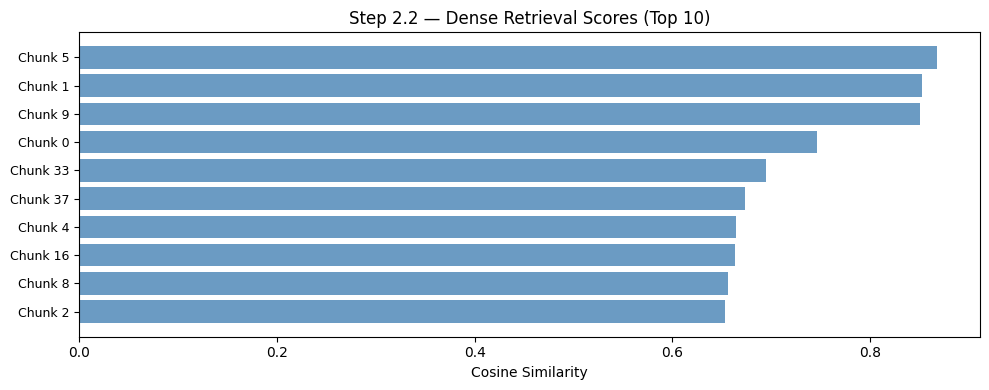

In [95]:
TOP_K_FETCH = 20
query_emb  = embedder.encode([TEST_QUERY]).tolist()
dense_res  = collection.query(
    query_embeddings=query_emb,
    n_results=min(TOP_K_FETCH, len(chunks)),
    include=['documents', 'metadatas', 'distances']
)

dense_ids   = dense_res['ids'][0]
dense_docs  = dense_res['documents'][0]
dense_dists = dense_res['distances'][0]
dense_sims  = [1 - d for d in dense_dists]

print(f'Dense retrieval → top {len(dense_ids)} candidates')
print(f'\nTop-5 Dense Results:')
df_dense = pd.DataFrame({
    'rank':       range(1, 6),
    'chunk_id':   [d.split('__chunk_')[1] for d in dense_ids[:5]],
    'similarity': [f'{s:.4f}' for s in dense_sims[:5]],
    'preview':    [d[:80]+'…' for d in dense_docs[:5]]
})
display(df_dense.to_html(index=False), metadata=dict(isolated=True))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(dense_sims[:10]), 0, -1), dense_sims[:10], color='steelblue', alpha=0.8)
ax.set_xlabel('Cosine Similarity')
ax.set_title('Step 2.2 — Dense Retrieval Scores (Top 10)')
ax.set_yticks(range(len(dense_sims[:10]), 0, -1))
ax.set_yticklabels([f'Chunk {d.split("__chunk_")[1]}' for d in dense_ids[:10]], fontsize=9)
plt.tight_layout()
plt.show()

2.3 Step 2: BM25 Sparse Retrieval

In [94]:
from rank_bm25 import BM25Okapi

all_res   = collection.get(include=['documents', 'metadatas'])
all_ids   = all_res['ids']
all_docs  = all_res['documents']
all_metas = all_res['metadatas']

tokenized = [d.lower().split() for d in all_docs]
bm25      = BM25Okapi(tokenized)
bm25_sc   = bm25.get_scores(TEST_QUERY.lower().split())
top_bm25  = np.argsort(bm25_sc)[::-1][:TOP_K_FETCH]
bm25_ids  = [all_ids[i] for i in top_bm25]

print(f'BM25 retrieval to top {len(bm25_ids)} candidates')
print(f'\nTop-5 BM25 Results:')
df_bm25 = pd.DataFrame({
    'rank':      range(1, 6),
    'chunk_id':  [b.split('__chunk_')[1] for b in bm25_ids[:5]],
    'bm25_score':[f'{bm25_sc[top_bm25[i]]:.4f}' for i in range(5)],
    'preview':   [all_docs[top_bm25[i]][:80]+'…' for i in range(5)]
})
display(df_bm25.to_html(index=False), metadata=dict(isolated=True))

# Overlap analysis
dense_set = set(dense_ids[:10])
bm25_set  = set(bm25_ids[:10])
overlap   = dense_set & bm25_set
print(f'\n Overlap between Dense top-10 and BM25 top-10: {len(overlap)} chunks')
print(f'   Dense-only: {len(dense_set - bm25_set)} | BM25-only: {len(bm25_set - dense_set)} | Shared: {len(overlap)}')

BM25 retrieval to top 20 candidates

Top-5 BM25 Results:


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>rank</th>\n      <th>chunk_id</th>\n      <th>bm25_score</th>\n      <th>preview</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>1</td>\n      <td>5</td>\n      <td>7.7280</td>\n      <td>The explanation produced by LIME is obtained by the following: f → Black-box mod…</td>\n    </tr>\n    <tr>\n      <td>2</td>\n      <td>8</td>\n      <td>6.2909</td>\n      <td>Pick an instance 𝑥 to explain. Create many similar but slightly different sample…</td>\n    </tr>\n    <tr>\n      <td>3</td>\n      <td>16</td>\n      <td>4.2710</td>\n      <td>Example Assume the model : 𝑓 𝑥 = 3 + 2𝑥1 + 4𝑥2 Explain the prediction for the in…</td>\n    </tr>\n    <tr>\n      <td>4</td>\n      <td>35</td>\n      <td>4.1673</td>\n      <td>Counterfactual examples generated by DiCE are closely related to necessity and s…</td>\n    </tr>\n    <tr>\n      <td>5</td>\n      <td>9</td>\n      <td>3.5879</td>\


 Overlap between Dense top-10 and BM25 top-10: 7 chunks
   Dense-only: 3 | BM25-only: 3 | Shared: 7


2.4 Step 3: Reciprocal Rank Fusion (RRF)

Step 2.4 — RRF Fusion: Top 10 after merging


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>rank</th>\n      <th>chunk_id</th>\n      <th>rrf_score</th>\n      <th>in_dense</th>\n      <th>in_bm25</th>\n      <th>preview</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>1</td>\n      <td>5</td>\n      <td>0.032787</td>\n      <td>✓</td>\n      <td>✓</td>\n      <td>The explanation produced by LIME is obtained by the following: f → Bla…</td>\n    </tr>\n    <tr>\n      <td>2</td>\n      <td>9</td>\n      <td>0.031258</td>\n      <td>✓</td>\n      <td>✓</td>\n      <td>The black-box model’s complex decision function f (unknown to LIME) is…</td>\n    </tr>\n    <tr>\n      <td>3</td>\n      <td>1</td>\n      <td>0.030622</td>\n      <td>✓</td>\n      <td>✓</td>\n      <td>Local Interpretable Model-Agnostic Explanations (LIME) Local Interpret…</td>\n    </tr>\n    <tr>\n      <td>4</td>\n      <td>8</td>\n      <td>0.030622</td>\n      <td>✓</td>\n      <td>✓</td>\n      <td

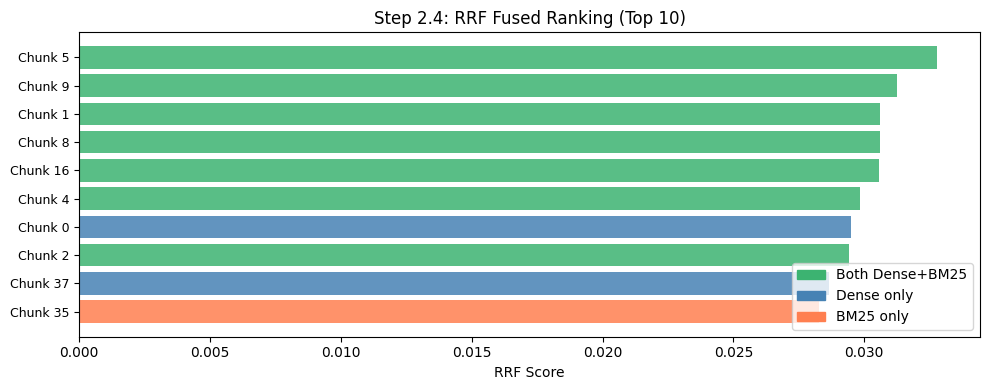

In [78]:
def rrf(dense_ids, bm25_ids, k=60):
    """Reciprocal Rank Fusion — higher = better combined rank."""
    scores = {}
    for rank, doc_id in enumerate(dense_ids):
        scores[doc_id] = scores.get(doc_id, 0) + 1 / (k + rank + 1)
    for rank, doc_id in enumerate(bm25_ids):
        scores[doc_id] = scores.get(doc_id, 0) + 1 / (k + rank + 1)
    return sorted(scores, key=scores.get, reverse=True), scores

fused_ids, rrf_scores = rrf(dense_ids, bm25_ids)
fused_ids = fused_ids[:TOP_K_FETCH]


id_to_doc  = dict(zip(all_ids, all_docs))
id_to_meta = dict(zip(all_ids, all_metas))

print('Step 2.4 — RRF Fusion: Top 10 after merging')
df_rrf = pd.DataFrame([
    {
        'rank':      i+1,
        'chunk_id':  cid.split('__chunk_')[1],
        'rrf_score': f'{rrf_scores.get(cid, 0):.6f}',
        'in_dense':  '✓' if cid in dense_set else '—',
        'in_bm25':   '✓' if cid in bm25_set else '—',
        'preview':   id_to_doc.get(cid, '')[:70]+'…'
    }
    for i, cid in enumerate(fused_ids[:10])
])
display(df_rrf.to_html(index=False), metadata=dict(isolated=True))

# Venn-style comparison
fig, ax = plt.subplots(figsize=(10, 4))
top10_fused = fused_ids[:10]
colors = []
for cid in top10_fused:
    if cid in dense_set and cid in bm25_set:
        colors.append('mediumseagreen')
    elif cid in dense_set:
        colors.append('steelblue')
    else:
        colors.append('coral')

ax.barh(range(10, 0, -1), [rrf_scores.get(c, 0) for c in top10_fused], color=colors, alpha=0.85)
ax.set_xlabel('RRF Score')
ax.set_title('Step 2.4: RRF Fused Ranking (Top 10)')
ax.set_yticks(range(10, 0, -1))
ax.set_yticklabels([f'Chunk {c.split("__chunk_")[1]}' for c in top10_fused], fontsize=9)

patches = [
    mpatches.Patch(color='mediumseagreen', label='Both Dense+BM25'),
    mpatches.Patch(color='steelblue', label='Dense only'),
    mpatches.Patch(color='coral', label='BM25 only'),
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

2.5 Step 4: CrossEncoder Reranking

Loading reranker: cross-encoder/ms-marco-MiniLM-L-6-v2

 Reranked - kept top 6 chunks for the LLM


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>rank</th>\n      <th>page</th>\n      <th>ce_score</th>\n      <th>preview</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>1</td>\n      <td>14</td>\n      <td>7.5827</td>\n      <td>The black-box model’s complex decision function f (unknown to LIME) is represented backgro…</td>\n    </tr>\n    <tr>\n      <td>2</td>\n      <td>2</td>\n      <td>7.1561</td>\n      <td>Local Interpretable Model-Agnostic Explanations (LIME) Local Interpretable Model-Agnostic …</td>\n    </tr>\n    <tr>\n      <td>3</td>\n      <td>10</td>\n      <td>5.4453</td>\n      <td>The explanation produced by LIME is obtained by the following: f → Black-box model. g → In…</td>\n    </tr>\n    <tr>\n      <td>4</td>\n      <td>13</td>\n      <td>-1.0432</td>\n      <td>Pick an instance 𝑥 to explain. Create many similar but slightly different samples (𝑧𝑖′ ). …</td>\n    </tr>\n    <tr>\n      <td>5</td>\n    

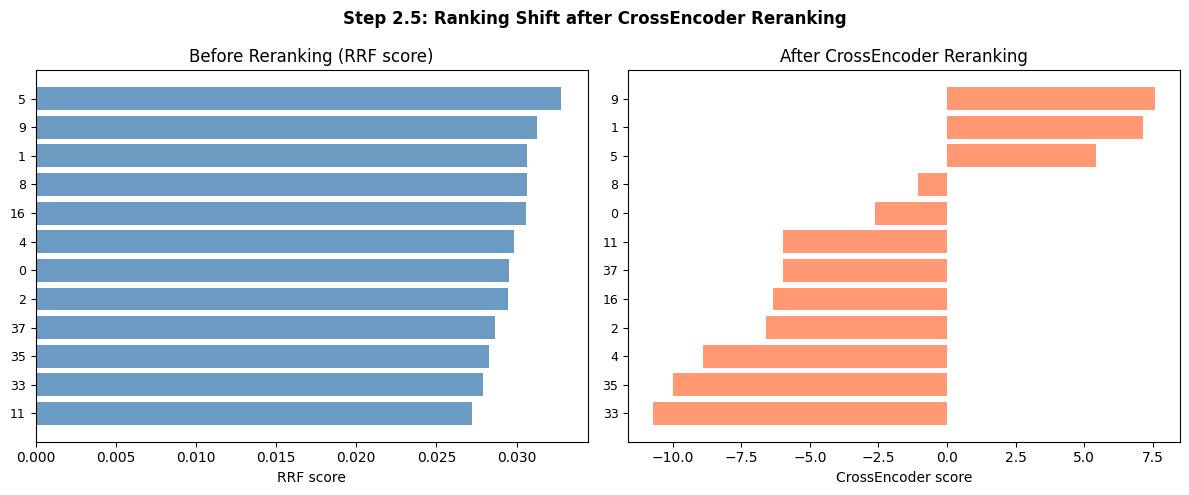

In [79]:
from sentence_transformers import CrossEncoder

RERANK_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
TOP_K_FINAL  = 6

print(f'Loading reranker: {RERANK_MODEL}')
reranker = CrossEncoder(RERANK_MODEL)

candidates = [(cid, id_to_doc[cid]) for cid in fused_ids if cid in id_to_doc]
pairs      = [(TEST_QUERY, text) for _, text in candidates]
scores_raw = reranker.predict(pairs)
ranked     = sorted(zip(candidates, scores_raw), key=lambda x: x[1], reverse=True)

final_chunks = [
    {
        'text':   text,
        'source': id_to_meta.get(cid, {}).get('source', '?'),
        'page':   id_to_meta.get(cid, {}).get('page', '?'),
        'score':  round(float(sc), 4),
    }
    for (cid, text), sc in ranked[:TOP_K_FINAL]
]

print(f'\n Reranked - kept top {TOP_K_FINAL} chunks for the LLM')
df_final = pd.DataFrame([
    {'rank': i+1, 'page': c['page'], 'ce_score': c['score'],
     'preview': c['text'][:90]+'…'}
    for i, c in enumerate(final_chunks)
])
display(df_final.to_html(index=False), metadata=dict(isolated=True))

pre_ids  = [c for c, _ in candidates[:TOP_K_FINAL]]
post_ids = [c for (c, _), _ in ranked[:TOP_K_FINAL]]
rrf_order  = {cid: i for i, (cid, _) in enumerate(candidates)}
post_order = {cid: i for i, ((cid, _), _) in enumerate(ranked)}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
all_cands = [c for c, _ in candidates[:12]]
rrf_sc   = [rrf_scores.get(c, 0) for c in all_cands]
ce_sc    = [float(s) for (_, _), s in
             sorted(zip(candidates, scores_raw), key=lambda x: [c for c, _ in candidates].index(x[0][0]))][:12]

axes[0].barh(range(12, 0, -1), rrf_sc, color='steelblue', alpha=0.8)
axes[0].set_title('Before Reranking (RRF score)')
axes[0].set_xlabel('RRF score')
axes[0].set_yticks(range(12, 0, -1))
axes[0].set_yticklabels([c.split('__chunk_')[1] for c in all_cands], fontsize=9)

sorted_by_ce = sorted(zip(all_cands, scores_raw[:12]), key=lambda x: x[1], reverse=True)
axes[1].barh(range(12, 0, -1),
             [s for _, s in sorted_by_ce],
             color='coral', alpha=0.8)
axes[1].set_title('After CrossEncoder Reranking')
axes[1].set_xlabel('CrossEncoder score')
axes[1].set_yticks(range(12, 0, -1))
axes[1].set_yticklabels([c.split('__chunk_')[1] for c, _ in sorted_by_ce], fontsize=9)

plt.suptitle('Step 2.5: Ranking Shift after CrossEncoder Reranking', fontweight='bold')
plt.tight_layout()
plt.show()

2.6: Step 5: LLM Generation (Llama 3.3 70B)

In [80]:
from groq import Groq

GROQ_MODEL = 'llama-3.3-70b-versatile'
_groq      = Groq(api_key=os.environ['GROQ_API_KEY'])

def format_context(chunks):
    return '\n\n---\n\n'.join(
        f'[{i+1}] {c["source"]}, Page {c["page"]}:\n{c["text"]}'
        for i, c in enumerate(chunks)
    )

SYSTEM = ('You are a helpful study assistant. '
          'Answer using ONLY the document excerpts provided. '
          'Cite sources as [Doc: filename, Page: N].')

context    = format_context(final_chunks)
user_msg   = (f'Document excerpts:\n{context}\n\nQuestion: {TEST_QUERY}')

resp = _groq.chat.completions.create(
    model=GROQ_MODEL,
    messages=[
        {'role': 'system',  'content': SYSTEM},
        {'role': 'user',    'content': user_msg},
    ],
    temperature=0.2,
    max_tokens=512,
)

generated_answer = resp.choices[0].message.content

display(Markdown(f'**Query:** {TEST_QUERY}'))
display(Markdown('---'))
display(Markdown(f'**Answer:**\n\n{generated_answer}'))

**Query:** How does LIME explain a black-box model prediction?

---

**Answer:**

LIME explains a black-box model prediction by approximating it locally with an interpretable model [Doc: Module 5.pptx, Page 2]. It does this by sampling instances, getting predictions using the black-box model, and weighing them by their proximity to the instance being explained [Doc: Module 5.pptx, Page 14]. The process involves creating many similar but slightly different samples, seeing how the black-box model behaves on them, weighting them by closeness to the original instance, and training a simplified, sparse linear model [Doc: Module 5.pptx, Page 13]. The resulting explanation is locally faithful, meaning it accurately represents the black-box model's behavior in the vicinity of the instance being explained, but not globally [Doc: Module 5.pptx, Page 14].

STAGE 3: Evaluation


3.1 Upload Test Document & Auto-Generate QA Pairs

In [81]:
eval_upload = widgets.FileUpload(
    accept='.pdf,.pptx,.docx,.txt',
    multiple=False,
    description='Upload Test Doc'
)
display(eval_upload)
print('  Upload the document to generate evaluation QA pairs from.')

FileUpload(value=(), accept='.pdf,.pptx,.docx,.txt', description='Upload Test Doc')

  Upload the document to generate evaluation QA pairs from.


In [82]:
if eval_upload.value:
    ev_item = eval_upload.value[0]
    ev_name = ev_item['name']
    ev_path  = ev_name
    with open(ev_path, 'wb') as f:
        f.write(ev_item['content'])
    print(f' Eval doc: {ev_name}')
else:
    ev_path = file_path
    ev_name = file_name
    print(f' No separate eval doc uploaded; using knowledge doc: {ev_name}')

eval_pages  = parse_file(ev_path, ev_name)
eval_chunks = semantic_chunk(eval_pages)
print(f'   Parsed {len(eval_chunks)} chunks from eval document')

 No separate eval doc uploaded; using knowledge doc: Module 5.pptx
   Parsed 45 chunks from eval document


In [83]:
import random, time

N_QA_PAIRS = 8   

# Sample diverse chunks from across the document
step = max(1, len(eval_chunks) // N_QA_PAIRS)
sampled = [eval_chunks[i * step] for i in range(N_QA_PAIRS)]

def generate_qa_from_chunk(chunk_text):
    """Ask Groq to produce one Q+A from a chunk."""
    prompt = f"""Read the following passage and generate exactly ONE question and its correct answer.

Rules:
- Question must be answerable ONLY from this passage.
- Answer should be 1-3 sentences, factual, and specific.
- Output ONLY valid JSON: {{"question": "...", "answer": "..."}}
- No extra text, no markdown fences.

Passage:
{chunk_text[:600]}"""
    
    resp = _groq.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.3,
        max_tokens=200,
    )
    raw = resp.choices[0].message.content.strip()
    raw = re.sub(r'^```json|```$', '', raw, flags=re.MULTILINE).strip()
    return json.loads(raw)

print(f'Generating {N_QA_PAIRS} QA pairs via Groq')
qa_pairs = []
for i, chunk in enumerate(sampled):
    try:
        qa = generate_qa_from_chunk(chunk['text'])
        qa['source_page'] = chunk['page']
        qa_pairs.append(qa)
        print(f'  [{i+1}/{N_QA_PAIRS}] Page {chunk["page"]}: {qa["question"][:60]}…')
    except Exception as e:
        print(f'  [{i+1}/{N_QA_PAIRS}] Skipped: {e}')
    time.sleep(0.5)  

print(f'\nGenerated {len(qa_pairs)} QA pairs')

Generating 8 QA pairs via Groq
  [1/8] Page 1: What are the XAI techniques covered in Module 5?…
  [2/8] Page 10: What is the purpose of the complexity penalty Ω(g) in LIME?…
  [3/8] Page 17: What is the range of the sample index i?…
  [4/8] Page 28: What are the two major approaches to calculate SHAP values?…
  [5/8] Page 33: What is the task to be performed on X2?…
  [6/8] Page 42: What type of layers does the LRP-0 formula work for?…
  [7/8] Page 47: What type of networks is the LRP-z⁺ Rule ideal for?…
  [8/8] Page 52: What happens to the model output when a necessary feature is…

Generated 8 QA pairs


In [84]:

df_qa = pd.DataFrame(qa_pairs)[['source_page', 'question', 'answer']]
df_qa.columns = ['Page', 'Question', 'Reference Answer']
display(df_qa.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

,Page,Question,Reference Answer
0,1,What are the XAI techniques covered in Module 5?,"The XAI techniques covered in Module 5 include Local Interpretable Model-Agnostic Explanations (LIME), Shapley Additive exPlanations (SHAP), Diverse Counterfactual Explanations (DiCE), and Layer wise Relevance Propagation (LRP)."
1,10,What is the purpose of the complexity penalty Ω(g) in LIME?,"The complexity penalty Ω(g) keeps the explanation interpretable by making the surrogate model sparse and simple, for example through L1 regularization, which forces many coefficients to zero."
2,17,What is the range of the sample index i?,The sample index i ranges from 1 to N.
3,28,What are the two major approaches to calculate SHAP values?,The two major approaches to calculate SHAP values are Exact SHAP Values and Approximate SHAP Values.
4,33,What is the task to be performed on X2?,The task to be performed on X2 is to calculate Shapely values.
5,42,What type of layers does the LRP-0 formula work for?,The LRP-0 formula works for fully connected and convolutional layers.
6,47,What type of networks is the LRP-z⁺ Rule ideal for?,"The LRP-z⁺ Rule is ideal for networks with ReLU activations, where negative activations carry little meaning."
7,52,What happens to the model output when a necessary feature is changed?,"The model output changes when a necessary feature is changed, while keeping every other feature constant."


3.2 Run Full RAG Pipeline on Every QA Pair

In [85]:
def full_retrieve(query, top_k=TOP_K_FINAL):
    """Full pipeline: dense + BM25 + RRF + reranker."""
    q_emb     = embedder.encode([query]).tolist()
    d_res     = collection.query(query_embeddings=q_emb,
                                  n_results=min(TOP_K_FETCH, len(chunks)),
                                  include=['documents','metadatas','distances'])
    d_ids  = d_res['ids'][0]
    id_doc = dict(zip(d_res['ids'][0], d_res['documents'][0]))
    id_met = dict(zip(d_res['ids'][0], d_res['metadatas'][0]))

    bm_sc  = bm25.get_scores(query.lower().split())
    tb     = np.argsort(bm_sc)[::-1][:TOP_K_FETCH]
    b_ids  = [all_ids[i] for i in tb]
    for i in tb:
        if all_ids[i] not in id_doc:
            id_doc[all_ids[i]] = all_docs[i]
            id_met[all_ids[i]] = all_metas[i]

    fused, _ = rrf(d_ids, b_ids)
    cands    = [(cid, id_doc[cid]) for cid in fused[:TOP_K_FETCH] if cid in id_doc]
    pairs_re = [(query, t) for _, t in cands]
    sc       = reranker.predict(pairs_re)
    ranked_c = sorted(zip(cands, sc), key=lambda x: x[1], reverse=True)
    return [
        {'text': t, 'source': id_met.get(cid,{}).get('source','?'),
         'page': id_met.get(cid,{}).get('page','?'), 'score': round(float(s),4)}
        for (cid, t), s in ranked_c[:top_k]
    ]

def full_generate(question, ctx_chunks):
    ctx = format_context(ctx_chunks)
    r   = _groq.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {'role': 'system', 'content': SYSTEM},
            {'role': 'user',   'content': f'Excerpts:\n{ctx}\n\nQuestion: {question}'}
        ],
        temperature=0.2, max_tokens=400,
    )
    return r.choices[0].message.content

print(f'Running RAG on {len(qa_pairs)} questions')
results = []
for i, qa in enumerate(qa_pairs):
    ctx_chunks = full_retrieve(qa['question'])
    answer     = full_generate(qa['question'], ctx_chunks)
    results.append({
        'question':    qa['question'],
        'reference':   qa['answer'],
        'generated':   answer,
        'contexts':    [c['text'] for c in ctx_chunks],
        'ctx_chunks':  ctx_chunks,
    })
    print(f'  [{i+1}/{len(qa_pairs)}]')
    time.sleep(0.3)

print('\nRAG answers generated')

Running RAG on 8 questions
  [1/8]
  [2/8]
  [3/8]
  [4/8]
  [5/8]
  [6/8]
  [7/8]
  [8/8]

RAG answers generated


3.3 Metric 1: Faithfulness

Does the generated answer contain only claims that are grounded in the retrieved context?  

In [86]:
def score_faithfulness(question, answer, contexts):
    ctx_str = '\n---\n'.join(contexts[:3])
    prompt  = f"""You are an evaluation judge.

Context passages:
{ctx_str}

Generated Answer:
{answer}

Task: Score how faithfully the answer is supported by the context passages.
- 1.0 = every claim is directly supported by the context
- 0.5 = partially supported; some unsupported claims
- 0.0 = answer contains mostly fabricated information

Respond with ONLY a JSON: {{"score": <float 0-1>, "reason": "<one sentence>"}}
No markdown fences."""

    r   = _groq.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.0, max_tokens=120,
    )
    raw = r.choices[0].message.content.strip()
    raw = re.sub(r'^```json|```$', '', raw, flags=re.MULTILINE).strip()
    return json.loads(raw)

print('Scoring Faithfulness')
for res in results:
    try:
        ev = score_faithfulness(res['question'], res['generated'], res['contexts'])
        res['faithfulness']        = ev['score']
        res['faithfulness_reason'] = ev['reason']
    except:
        res['faithfulness']        = 0.5
        res['faithfulness_reason'] = 'parse error'
    time.sleep(0.3)

avg_f = np.mean([r['faithfulness'] for r in results])
print(f'\n Avg Faithfulness: {avg_f:.3f}')

Scoring Faithfulness

 Avg Faithfulness: 1.000


3.4 Metric 2: Answer Relevancy

Does the generated answer actually address the question? 
Method: Embed the question and the answer, compute cosine similarity.

In [87]:
from sklearn.metrics.pairwise import cosine_similarity

def score_relevancy(question, answer):
    q_emb = embedder.encode([question])
    a_emb = embedder.encode([answer])
    return float(cosine_similarity(q_emb, a_emb)[0][0])

for res in results:
    res['relevancy'] = score_relevancy(res['question'], res['generated'])

avg_r = np.mean([r['relevancy'] for r in results])
print(f' Avg Answer Relevancy: {avg_r:.3f}')

 Avg Answer Relevancy: 0.834


3.5 Metric 3: Context Precision & Recall

Precision: What fraction of retrieved chunks are relevant to the question?  
Recall: Does the context contain enough information to answer the question?  


In [88]:
def score_context(question, reference, ctx_chunks):
    relevant = []
    for c in ctx_chunks[:4]:
        prompt = f"""Is the following passage relevant to answering this question?

Question: {question}
Passage: {c['text'][:400]}

Answer with ONLY: {{"relevant": true}} or {{"relevant": false}}
No other text."""
        r   = _groq.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{'role':'user','content':prompt}],
            temperature=0.0, max_tokens=30,
        )
        raw = r.choices[0].message.content.strip()
        raw = re.sub(r'^```json|```$','',raw,flags=re.MULTILINE).strip()
        try:
            relevant.append(json.loads(raw).get('relevant', False))
        except:
            relevant.append(False)
        time.sleep(0.2)

    precision = sum(relevant) / len(relevant) if relevant else 0

    combined = ' '.join(c['text'] for c in ctx_chunks[:4])
    recall_prompt = f"""Does the following context contain sufficient information to produce this reference answer?

Reference answer: {reference}
Context: {combined[:800]}

Score from 0.0 to 1.0. Respond ONLY: {{"recall": <float>}}"""
    r2  = _groq.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{'role':'user','content':recall_prompt}],
        temperature=0.0, max_tokens=30,
    )
    raw2 = r2.choices[0].message.content.strip()
    raw2 = re.sub(r'^```json|```$','',raw2,flags=re.MULTILINE).strip()
    try:
        recall = json.loads(raw2).get('recall', 0.0)
    except:
        recall = 0.0

    return precision, recall, relevant

print('Scoring Context Precision & Recall')
for i, res in enumerate(results):
    p, r, rel_flags = score_context(res['question'], res['reference'], res['ctx_chunks'])
    res['ctx_precision'] = p
    res['ctx_recall']    = r
    res['ctx_relevance_flags'] = rel_flags
    print(f'  [{i+1}/{len(results)}] Precision={p:.2f}  Recall={r:.2f}')
    time.sleep(0.3)

avg_p = np.mean([r['ctx_precision'] for r in results])
avg_rc = np.mean([r['ctx_recall'] for r in results])
print(f'\n Avg Context Precision: {avg_p:.3f}  |  Avg Context Recall: {avg_rc:.3f}')

Scoring Context Precision & Recall
  [1/8] Precision=0.75  Recall=1.00
  [2/8] Precision=0.50  Recall=1.00
  [3/8] Precision=0.25  Recall=1.00
  [4/8] Precision=1.00  Recall=1.00
  [5/8] Precision=0.25  Recall=1.00
  [6/8] Precision=0.75  Recall=1.00
  [7/8] Precision=0.50  Recall=1.00
  [8/8] Precision=0.75  Recall=1.00

 Avg Context Precision: 0.594  |  Avg Context Recall: 1.000


3.6 Metric 4 - BLEU & ROUGE

Measures n-gram overlap between generated answer and reference answer.

In [89]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

smoother     = SmoothingFunction().method1
rouge_engine = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

for res in results:
    ref_tokens = res['reference'].lower().split()
    gen_tokens = res['generated'].lower().split()

    # BLEU-1, BLEU-2
    res['bleu1'] = sentence_bleu([ref_tokens], gen_tokens,
                                  weights=(1,0,0,0), smoothing_function=smoother)
    res['bleu2'] = sentence_bleu([ref_tokens], gen_tokens,
                                  weights=(0.5,0.5,0,0), smoothing_function=smoother)

    # ROUGE
    rsc = rouge_engine.score(res['reference'], res['generated'])
    res['rouge1']  = rsc['rouge1'].fmeasure
    res['rouge2']  = rsc['rouge2'].fmeasure
    res['rougeL']  = rsc['rougeL'].fmeasure

print('BLEU & ROUGE scores computed ')
for k in ['bleu1','bleu2','rouge1','rouge2','rougeL']:
    print(f'  Avg {k:8s}: {np.mean([r[k] for r in results]):.4f}')

BLEU & ROUGE scores computed 
  Avg bleu1   : 0.5270
  Avg bleu2   : 0.4876
  Avg rouge1  : 0.7137
  Avg rouge2  : 0.6159
  Avg rougeL  : 0.6687


3.7 Results Table: All Metrics

In [90]:
metrics_df = pd.DataFrame([{
    'Q#':              i+1,
    'Question':        r['question'][:55]+'…',
    'Faithfulness':    round(r['faithfulness'], 3),
    'Relevancy':       round(r['relevancy'], 3),
    'Ctx Precision':   round(r['ctx_precision'], 3),
    'Ctx Recall':      round(r['ctx_recall'], 3),
    'BLEU-1':          round(r['bleu1'], 3),
    'ROUGE-L':         round(r['rougeL'], 3),
} for i, r in enumerate(results)])

# Append averages row
avg_row = {'Q#': 'AVG', 'Question': '—'}
for col in ['Faithfulness','Relevancy','Ctx Precision','Ctx Recall','BLEU-1','ROUGE-L']:
    avg_row[col] = round(metrics_df[col].mean(), 3)
metrics_df = pd.concat([metrics_df, pd.DataFrame([avg_row])], ignore_index=True)

def color_cell(val):
    if not isinstance(val, float): return ''
    if val >= 0.7:   return 'background-color: #c8f0c8'
    elif val >= 0.4: return 'background-color: #fef3c7'
    else:            return 'background-color: #fecaca'

num_cols = ['Faithfulness','Relevancy','Ctx Precision','Ctx Recall','BLEU-1','ROUGE-L']
display(
    metrics_df.style
      .applymap(color_cell, subset=num_cols)
      .set_properties(**{'text-align':'center'})
      .set_caption('Green ≥0.7   Yellow 0.4–0.7   Red <0.4')
)

,Q#,Question,Faithfulness,Relevancy,Ctx Precision,Ctx Recall,BLEU-1,ROUGE-L
0,1,What are the XAI techniques covered in Module 5?…,1.000000,0.844000,0.750000,1.000000,0.600000,0.800000
1,2,What is the purpose of the complexity penalty Ω(g) in L…,1.000000,0.917000,0.500000,1.000000,0.372000,0.535000
2,3,What is the range of the sample index i?…,1.000000,0.848000,0.250000,1.000000,0.412000,0.593000
3,4,What are the two major approaches to calculate SHAP val…,1.000000,0.871000,1.000000,1.000000,0.234000,0.370000
4,5,What is the task to be performed on X2?…,1.000000,0.702000,0.250000,1.000000,0.647000,0.800000
5,6,What type of layers does the LRP-0 formula work for?…,1.000000,0.842000,0.750000,1.000000,0.600000,0.786000
6,7,What type of networks is the LRP-z⁺ Rule ideal for?…,1.000000,0.832000,0.500000,1.000000,0.714000,0.850000
7,8,What happens to the model output when a necessary featu…,1.000000,0.814000,0.750000,1.000000,0.636000,0.615000
8,AVG,—,1.000000,0.834000,0.594000,1.000000,0.527000,0.669000


3.8 Evaluation Visualisation Dashboard

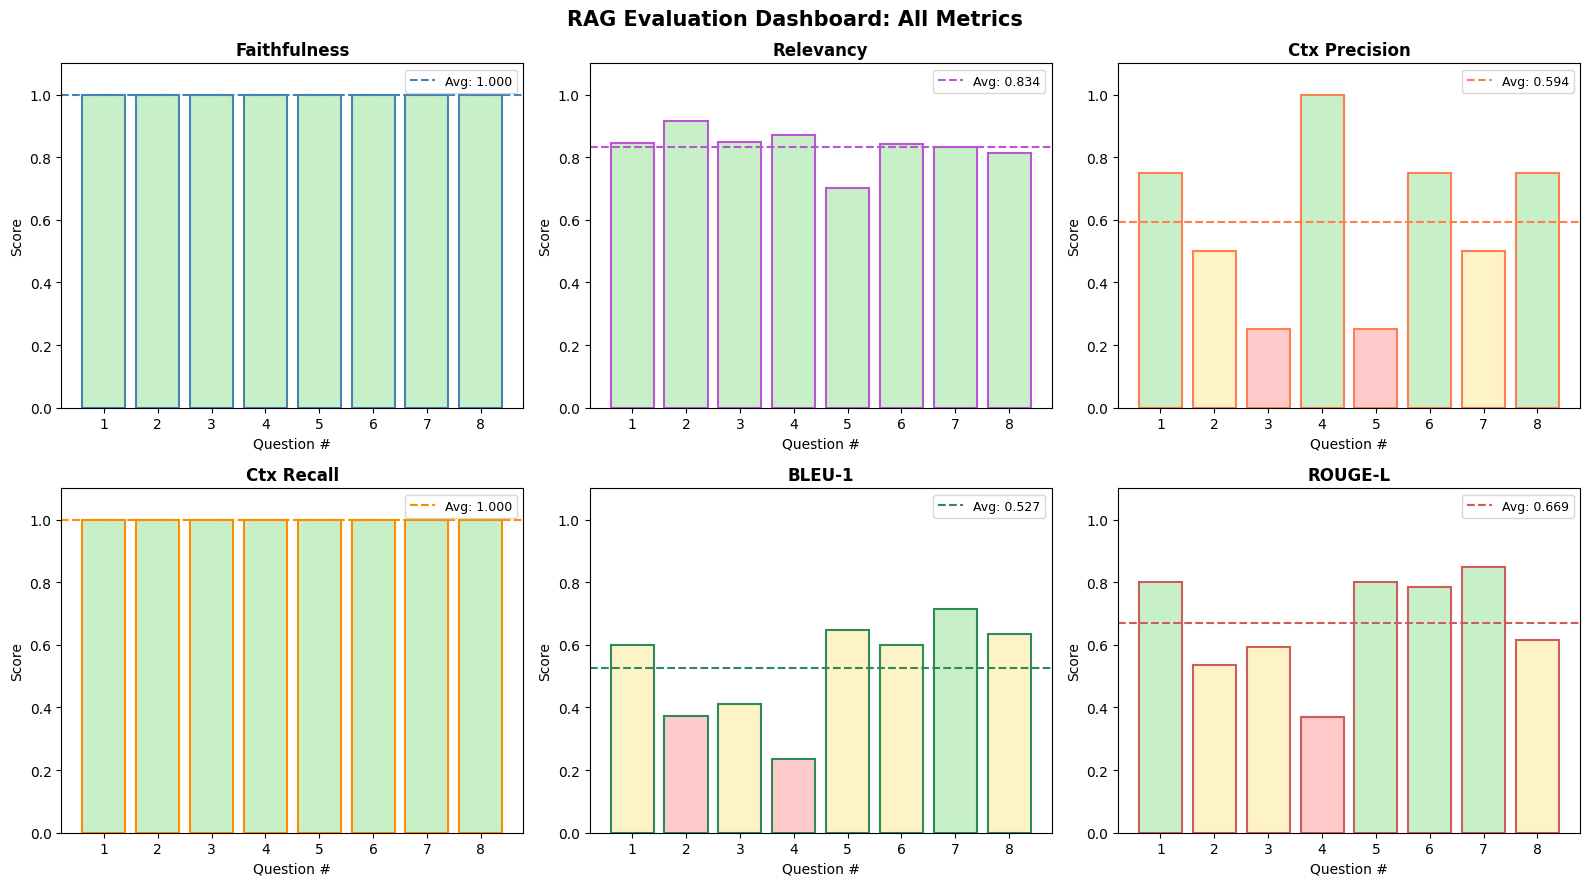

In [91]:
plot_df = metrics_df[metrics_df['Q#'] != 'AVG'].copy()
plot_df['Q#'] = plot_df['Q#'].astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('RAG Evaluation Dashboard: All Metrics', fontsize=15, fontweight='bold')

metric_info = [
    ('Faithfulness',  'steelblue',   'Does answer stay grounded in context?'),
    ('Relevancy',     'mediumorchid','Does answer address the question?'),
    ('Ctx Precision', 'coral',       'Are retrieved chunks actually relevant?'),
    ('Ctx Recall',    'darkorange',  'Is enough context retrieved?'),
    ('BLEU-1',        'seagreen',    'Unigram overlap with reference'),
    ('ROUGE-L',       'indianred',   'Longest common subsequence F1'),
]

for ax, (metric, color, desc) in zip(axes.flat, metric_info):
    vals = plot_df[metric].tolist()
    qs   = plot_df['Q#'].tolist()
    bar_colors = ['#c8f0c8' if v >= 0.7 else '#fef3c7' if v >= 0.4 else '#fecaca' for v in vals]
    bars = ax.bar(qs, vals, color=bar_colors, edgecolor=color, linewidth=1.5)
    avg  = np.mean(vals)
    ax.axhline(avg, color=color, linestyle='--', linewidth=1.5, label=f'Avg: {avg:.3f}')
    ax.set_ylim(0, 1.1)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Question #')
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.set_xticks(qs)

plt.tight_layout()
plt.show()

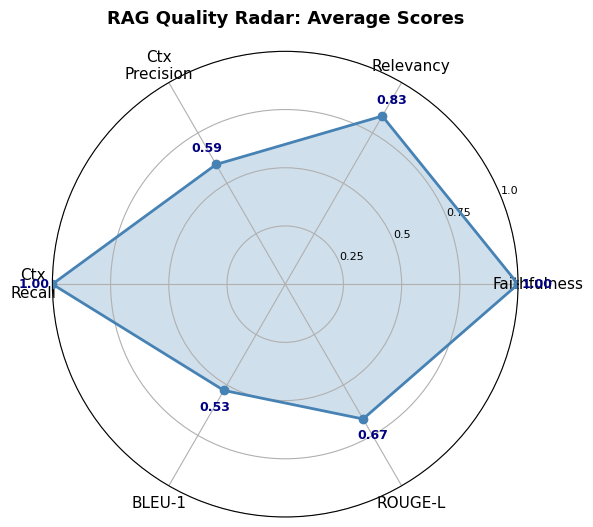


 Summary:
  Faithfulness     ████████████████████  1.000
  Relevancy        ████████████████░░░░  0.834
  Ctx Precision    ███████████░░░░░░░░░  0.594
  Ctx Recall       ████████████████████  1.000
  BLEU-1           ██████████░░░░░░░░░░  0.527
  ROUGE-L          █████████████░░░░░░░  0.669


In [92]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

avg_vals = [
    np.mean([r['faithfulness']  for r in results]),
    np.mean([r['relevancy']     for r in results]),
    np.mean([r['ctx_precision'] for r in results]),
    np.mean([r['ctx_recall']    for r in results]),
    np.mean([r['bleu1']         for r in results]),
    np.mean([r['rougeL']        for r in results]),
]
labels = ['Faithfulness','Relevancy','Ctx\nPrecision','Ctx\nRecall','BLEU-1','ROUGE-L']
N = len(labels)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
vals_r = avg_vals + [avg_vals[0]]
angles_r = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles_r, vals_r, 'o-', linewidth=2, color='steelblue')
ax.fill(angles_r, vals_r, alpha=0.25, color='steelblue')
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=8)
ax.set_title('RAG Quality Radar: Average Scores', fontsize=13, fontweight='bold', pad=20)

for angle, val, label in zip(angles, avg_vals, labels):
    ax.text(angle, val + 0.08, f'{val:.2f}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='navy')

plt.tight_layout()
plt.show()

print('\n Summary:')
for label, val in zip(['Faithfulness','Relevancy','Ctx Precision','Ctx Recall','BLEU-1','ROUGE-L'], avg_vals):
    bar = '█' * int(val * 20) + '░' * (20 - int(val * 20))
    print(f'  {label:16s} {bar}  {val:.3f}')

 3.9 Per-question Diagnostic View

In [93]:

for i, r in enumerate(results):
    f  = r['faithfulness']
    rv = r['relevancy']
    cp = r['ctx_precision']
    cr = r['ctx_recall']

    def badge(v):
        if v >= 0.7:   return f'<span style="background:#c8f0c8;padding:2px 6px;border-radius:4px">{v:.2f}</span>'
        elif v >= 0.4: return f'<span style="background:#fef3c7;padding:2px 6px;border-radius:4px">{v:.2f}</span>'
        else:          return f'<span style="background:#fecaca;padding:2px 6px;border-radius:4px">{v:.2f}</span>'

    display(HTML(f"""
    <div style='border:1px solid #ddd;border-radius:8px;padding:14px;margin:10px 0;font-family:sans-serif'>
      <b>Q{i+1}:</b> {r['question']}<br/><br/>
      <b>Reference:</b> <span style='color:#555'>{r['reference'][:200]}</span><br/>
      <b>Generated:</b> <span style='color:#333'>{r['generated'][:300]}…</span><br/><br/>
      <b>Scores:</b>
      Faithfulness {badge(f)} &nbsp;
      Relevancy {badge(rv)} &nbsp;
      Ctx Precision {badge(cp)} &nbsp;
      Ctx Recall {badge(cr)} &nbsp;
      BLEU-1 {badge(r['bleu1'])} &nbsp;
      ROUGE-L {badge(r['rougeL'])}<br/>
      <small style='color:#888'>Faithfulness note: {r.get('faithfulness_reason','—')}</small>
    </div>
    """))